In [1]:
import pandas as pd

df = pd.read_excel('../data/online_retail_II.xlsx', 
                   sheet_name='Year 2009-2010')
print(df.shape)
print(df.dtypes)
df.head(10)



(525461, 8)
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [8]:
df = df.dropna(subset=['Customer ID', 'Description'])
print(df.shape)                   

(417534, 8)


In [9]:
df.duplicated().sum()

np.int64(6771)

In [10]:
df = df.drop_duplicates()
print (df.shape)

(410763, 8)


In [11]:
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
print (df.shape)


(400916, 8)


In [12]:
df['Revenue'] = df['Quantity'] * df['Price']
print(df.shape)
df.head(10)
# df['Revenue'] = df['Quantity'] * df['Price']
# print(df.shape)
# df.head(10)

(400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,59.5
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,30.6
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,45.0


In [13]:
print("Total Transactions:", df.shape[0])
print("Total Columns:", df.shape[1])
print("Total Revenue:", df['Revenue'].sum().round(2))
print("Unique Customers:", df['Customer ID'].nunique())
print("Unique Countries:", df['Country'].nunique())

Total Transactions: 400916
Total Columns: 9
Total Revenue: 8798233.74
Unique Customers: 4312
Unique Countries: 37


In [14]:
print(df.shape)

(400916, 9)


In [15]:
country_revenue = df.groupby('Country').agg({'Revenue': sum}).round(2)
country_revenue = country_revenue.sort_values('Revenue' , ascending=False)
print (country_revenue.head(10))

                   Revenue
Country                   
United Kingdom  7381644.43
EIRE             356041.86
Netherlands      268784.35
Germany          202025.39
France           146107.07
Sweden            53147.99
Denmark           50906.85
Spain             47568.65
Switzerland       43921.39
Australia         31446.80


In [16]:
top_customers = df.groupby('Customer ID').agg({'Revenue':'sum'}).round(2)
top_customers = top_customers.sort_values('Revenue', ascending=False)
print(top_customers.head(10))

               Revenue
Customer ID           
18102.0      349164.35
14646.0      248396.50
14156.0      196549.74
14911.0      152121.22
13694.0      131443.19
17511.0       84541.17
15061.0       83284.38
16684.0       80489.21
16754.0       65500.07
17949.0       60117.60


In [17]:
top_products = df.groupby('Description').agg({'Quantity':'sum'})
top_products = top_products.sort_values('Quantity', ascending=False)
print(top_products.head(10))

                                    Quantity
Description                                 
WHITE HANGING HEART T-LIGHT HOLDER     56814
WORLD WAR 2 GLIDERS ASSTD DESIGNS      54610
BROCADE RING PURSE                     48166
PACK OF 72 RETRO SPOT CAKE CASES       45129
ASSORTED COLOUR BIRD ORNAMENT          44431
60 TEATIME FAIRY CAKE CASES            35656
PACK OF 60 PINK PAISLEY CAKE CASES     30871
JUMBO BAG RED RETROSPOT                29519
SMALL POPCORN HOLDER                   25703
BLACK AND WHITE PAISLEY FLOWER MUG     25685


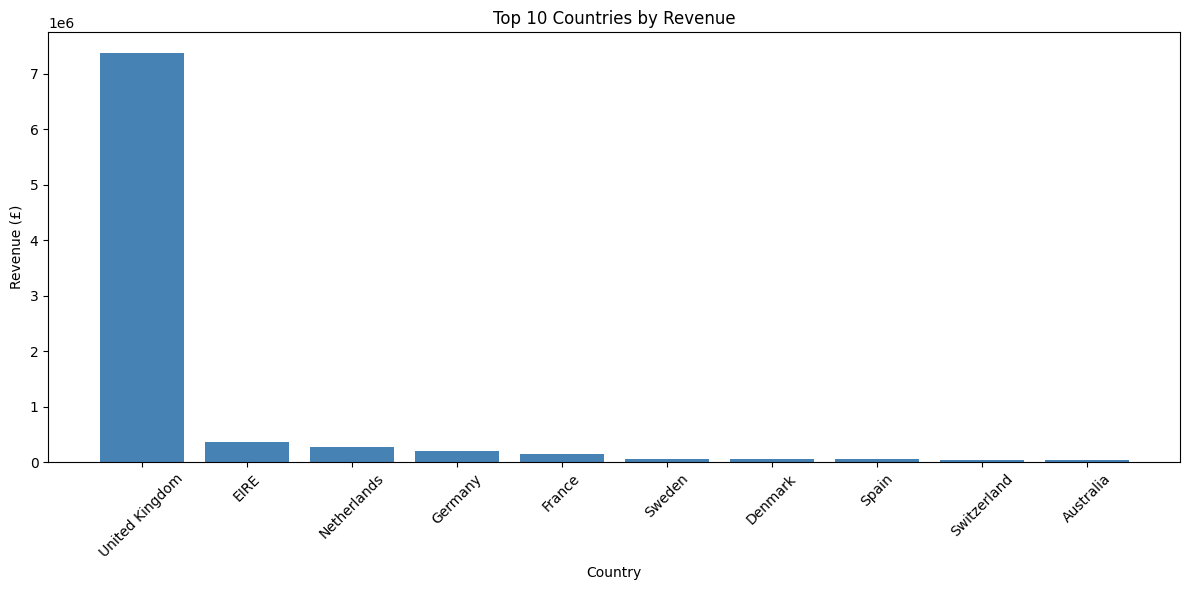

In [18]:
import matplotlib.pyplot as plt

top_countries = country_revenue.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_countries.index, top_countries['Revenue'], color='steelblue')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
print(df.shape)

(400916, 9)


In [20]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2010-12-10 20:01:00


In [21]:
rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('Revenue', 'sum')
).round(2)

print(rfm.shape)
rfm.head(10)

(4312, 3)


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93
12352.0,11,2,343.80
12353.0,44,1,317.76
12355.0,203,1,488.21
12356.0,16,3,3560.30


In [22]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm.head(10))

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
Customer ID                                                                
12346.0          165         11    372.86       2       5       2       252
12347.0            3          2   1323.32       5       2       4       524
12348.0           74          1    222.16       2       1       1       211
12349.0           43          3   2671.14       3       3       5       335
12351.0           11          1    300.93       5       1       2       512
12352.0           11          2    343.80       5       2       2       522
12353.0           44          1    317.76       3       1       2       312
12355.0          203          1    488.21       1       1       2       112
12356.0           16          3   3560.30       4       3       5       435
12357.0           24          2  12079.99       4       2       5       425


In [23]:
def label_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    
    if r >= 4 and f >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal'
    elif r >= 3:
        return 'Potential'
    elif r == 2:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(label_customer, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champion     1105
Lost          855
At Risk       848
Loyal         794
Potential     710
Name: count, dtype: int64


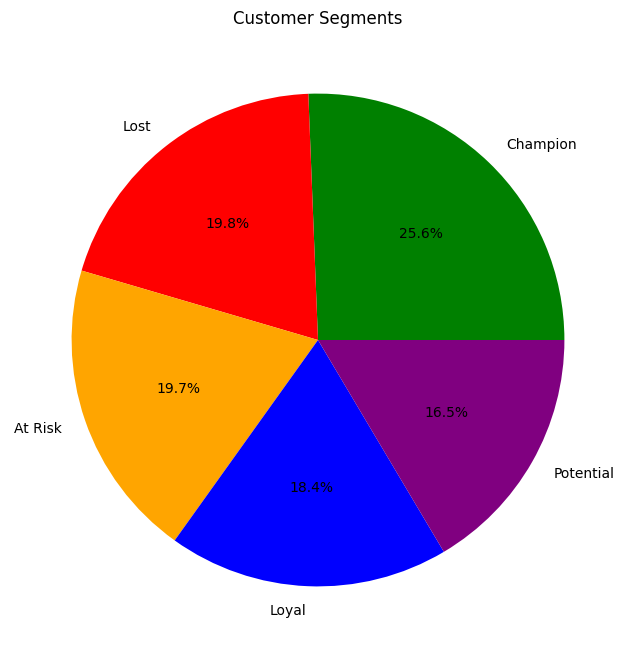

In [24]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(segment_counts, 
        labels=segment_counts.index, 
        autopct='%1.1f%%',
        colors=['green','red','orange','blue','purple'])
plt.title('Customer Segments')
plt.show()

In [25]:
rfm.to_csv('../outputs/rfm_segments.csv')
print("Saved!")


Saved!


In [26]:
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)
print(rfm['Churn'].value_counts())


Churn
0    2877
1    1435
Name: count, dtype: int64


In [29]:
# X = rfm[['Frequency', 'Monetary']]
# y = rfm['Churn']

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42
# )

# model = XGBClassifier(random_state=42)
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
# print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
# print("\nDetailed Report:")
# print(classification_report(y_test, y_pred))
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

Accuracy: 0.7115


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (3449, 2)
Test size: (863, 2)


In [31]:
from xgboost import XGBClassifier

model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [32]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7115

Detailed Report:
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       571
           1       0.59      0.49      0.53       292

    accuracy                           0.71       863
   macro avg       0.67      0.66      0.66       863
weighted avg       0.70      0.71      0.70       863



In [33]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (863, 2)


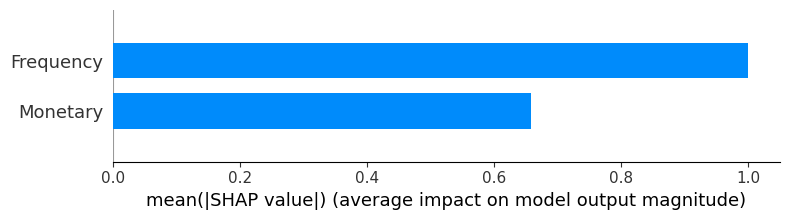

In [34]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [35]:
rfm['Churn_Probability'] = model.predict_proba(
    rfm[['Frequency', 'Monetary']])[:,1].round(4)

at_risk = rfm[rfm['Churn_Probability'] > 0.5]\
    .sort_values('Churn_Probability', ascending=False)

print(at_risk[['Frequency', 'Monetary', 
               'Segment', 'Churn_Probability']].head(10))

             Frequency  Monetary  Segment  Churn_Probability
Customer ID                                                 
14091.0              2   9530.08     Lost             0.9608
16917.0              1   1460.36     Lost             0.9418
15359.0              8    181.35     Lost             0.9417
16749.0              2   4157.88     Lost             0.9386
17133.0              5   9730.09  At Risk             0.9197
12378.0              1   1407.70     Lost             0.9171
12531.0              1   1807.98     Lost             0.9120
16180.0              5   5995.69  At Risk             0.9006
14855.0              5   5874.65  At Risk             0.9006
14875.0              1   1397.08  At Risk             0.9003


In [36]:
rfm.to_csv('../outputs/rfm_churn_scores.csv')
print("Saved!")

Saved!


In [37]:
segment_revenue = df.merge(
    rfm[['Segment']], 
    on='Customer ID'
)

segment_summary = segment_revenue.groupby('Segment').agg(
    Total_Revenue = ('Revenue', 'sum'),
    Total_Customers = ('Customer ID', 'nunique')
).round(2)

print(segment_summary)

           Total_Revenue  Total_Customers
Segment                                  
At Risk        923571.43              848
Champion      5835924.68             1105
Lost           521641.73              855
Loyal         1182875.82              794
Potential      334220.08              710


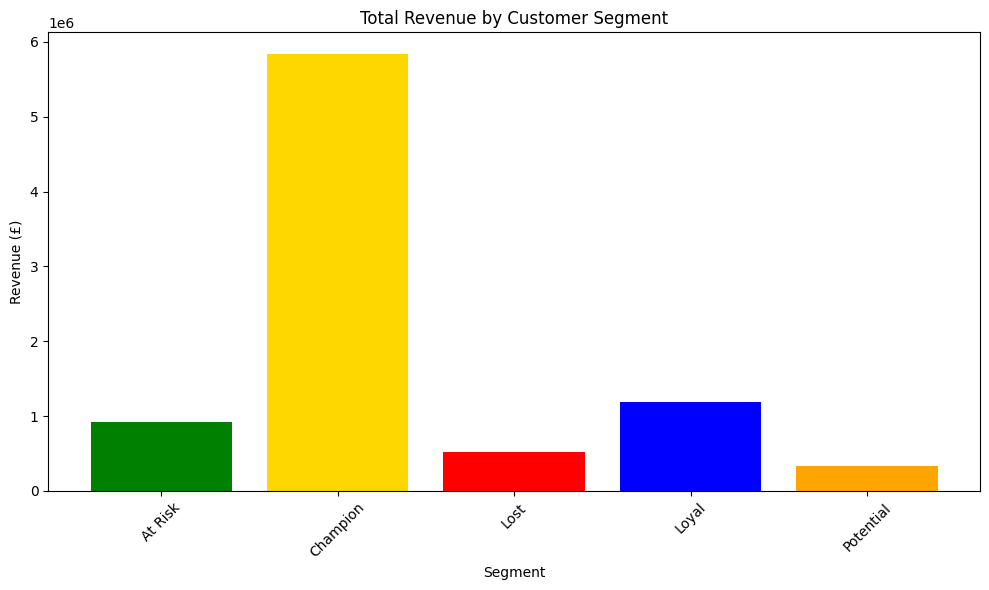

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(segment_summary.index, 
        segment_summary['Total_Revenue'],
        color=['green','gold','red','blue','orange'])
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
print("=" * 50)
print("   E-COMMERCE CHURN ANALYSIS — FINAL REPORT")
print("=" * 50)

print("\n DATASET:")
print(f"Total Transactions : {df.shape[0]:,}")
print(f"Total Customers    : {rfm.shape[0]:,}")
print(f"Total Revenue      : £{df['Revenue'].sum():,.2f}")

print("\n CUSTOMER SEGMENTS:")
for segment, count in rfm['Segment'].value_counts().items():
    pct = count/rfm.shape[0]*100
    print(f"{segment:12} : {count:,} customers ({pct:.1f}%)")

print("\n CHURN ANALYSIS:")
churned = rfm['Churn'].sum()
total = rfm.shape[0]
print(f"Churned Customers  : {churned:,} ({churned/total*100:.1f}%)")
print(f"Active Customers   : {total-churned:,} ({(total-churned)/total*100:.1f}%)")

print("\n REVENUE AT RISK:")
at_risk_rev = segment_summary.loc['At Risk','Total_Revenue']
lost_rev = segment_summary.loc['Lost','Total_Revenue']
print(f"At Risk Revenue    : £{at_risk_rev:,.2f}")
print(f"Lost Revenue       : £{lost_rev:,.2f}")
print(f"Total At Risk      : £{at_risk_rev+lost_rev:,.2f}")

print("\n ML MODEL:")
print(f"Algorithm          : XGBoost Classifier")
print(f"Accuracy           : 71.15%")
print(f"Top Churn Feature  : Frequency")

print("\n" + "=" * 50)
print("   END OF REPORT")
print("=" * 50)

   E-COMMERCE CHURN ANALYSIS — FINAL REPORT

 DATASET:
Total Transactions : 400,916
Total Customers    : 4,312
Total Revenue      : £8,798,233.74

 CUSTOMER SEGMENTS:
Champion     : 1,105 customers (25.6%)
Lost         : 855 customers (19.8%)
At Risk      : 848 customers (19.7%)
Loyal        : 794 customers (18.4%)
Potential    : 710 customers (16.5%)

 CHURN ANALYSIS:
Churned Customers  : 1,435 (33.3%)
Active Customers   : 2,877 (66.7%)

 REVENUE AT RISK:
At Risk Revenue    : £923,571.43
Lost Revenue       : £521,641.73
Total At Risk      : £1,445,213.16

 ML MODEL:
Algorithm          : XGBoost Classifier
Accuracy           : 71.15%
Top Churn Feature  : Frequency

   END OF REPORT


In [40]:
# Save RFM with churn scores
rfm.to_csv('../outputs/rfm_final.csv')

# Save segment summary
segment_summary.to_csv('../outputs/segment_summary.csv')

print("All files saved to outputs folder! ✅")

All files saved to outputs folder! ✅
